# NanoTrade Latency Benchmark Analysis

Reads raw latency samples produced by `latency_benchmark` and plots distribution + CDF.

Run the benchmark first from the project root:
```
./cmake-build-release/latency_benchmark
```

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

RESULTS_DIR = '../benchmarks/results'

datasets = {
    'ME processClientRequest (mixed)': os.path.join(RESULTS_DIR, 'me_total_latency.csv'),
    'ME order add (no-cross, resting)': os.path.join(RESULTS_DIR, 'ob_add_latency.csv'),
}

samples = {label: pd.read_csv(path)['latency_ns'].values
           for label, path in datasets.items() if os.path.exists(path)}

In [6]:
summary_rows = []
for label, s in samples.items():
    summary_rows.append({
        'metric': label,
        'count': len(s),
        'min': int(np.min(s)),
        'p50': int(np.percentile(s, 50)),
        'p90': int(np.percentile(s, 90)),
        'p99': int(np.percentile(s, 99)),
        'p99.9': int(np.percentile(s, 99.9)),
        'max': int(np.max(s)),
        'mean': int(np.mean(s)),
    })
pd.DataFrame(summary_rows).set_index('metric')

,count,min,p50,p90,p99,p99.9,max,mean
metric,,,,,,,,
ME processClientRequest (mixed),500000,14691,82931,291236,540866,755803,4665890,136735
"ME order add (no-cross, resting)",500000,14675,74396,88126,118548,211142,513548,67572


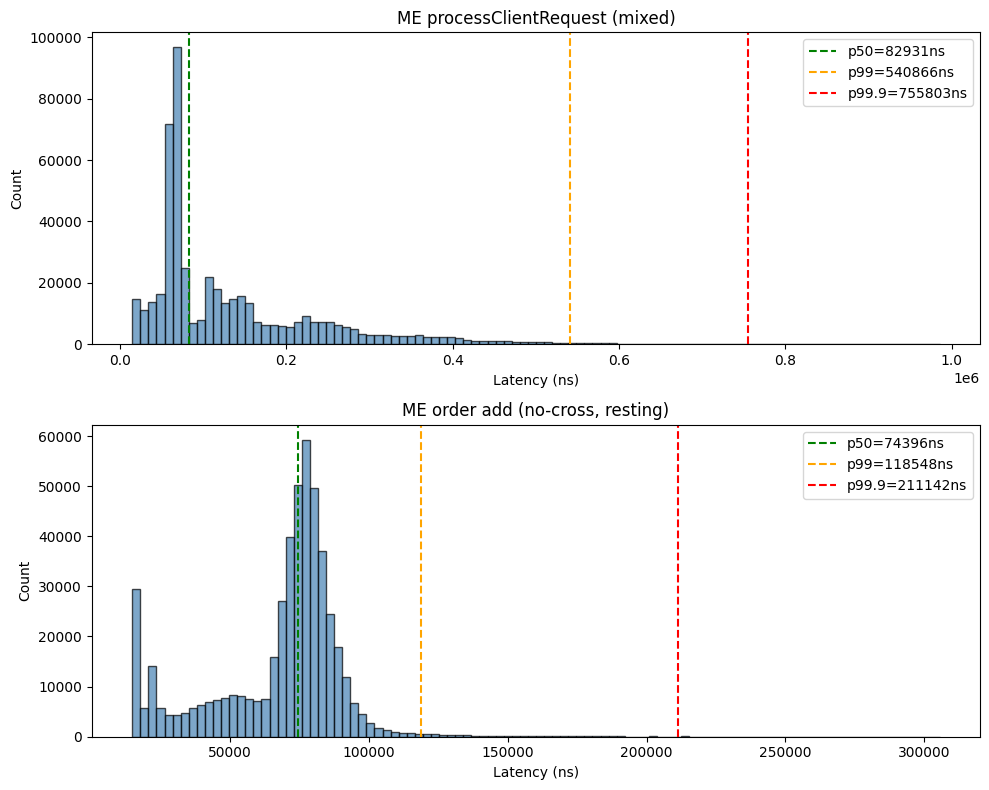

In [7]:
fig, axes = plt.subplots(len(samples), 1, figsize=(10, 4 * len(samples)))
if len(samples) == 1:
    axes = [axes]

for ax, (label, s) in zip(axes, samples.items()):
    upper = np.percentile(s, 99.99)
    clipped = s[s <= upper]
    ax.hist(clipped, bins=100, color='steelblue', edgecolor='black', alpha=0.7)
    for pct, color in [(50, 'green'), (99, 'orange'), (99.9, 'red')]:
        v = np.percentile(s, pct)
        ax.axvline(v, color=color, linestyle='--', label=f'p{pct}={int(v)}ns')
    ax.set_title(label)
    ax.set_xlabel('Latency (ns)')
    ax.set_ylabel('Count')
    ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'latency_histogram.png'), dpi=120)
plt.show()

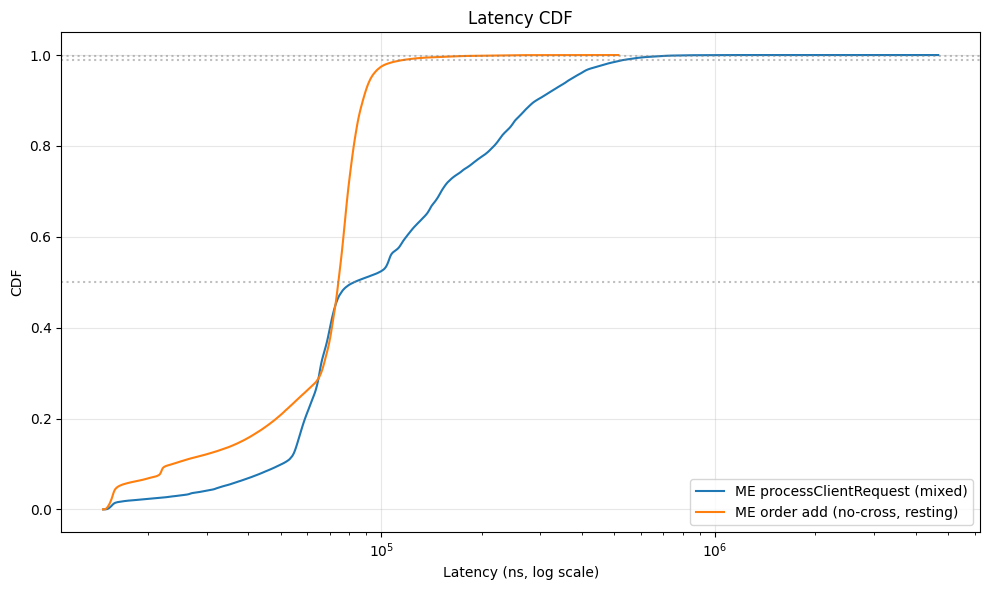

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))
for label, s in samples.items():
    sorted_s = np.sort(s)
    cdf = np.arange(1, len(sorted_s) + 1) / len(sorted_s)
    ax.plot(sorted_s, cdf, label=label)

ax.set_xscale('log')
ax.set_xlabel('Latency (ns, log scale)')
ax.set_ylabel('CDF')
ax.set_title('Latency CDF')
for p in [0.50, 0.99, 0.999]:
    ax.axhline(p, color='gray', linestyle=':', alpha=0.5)
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'latency_cdf.png'), dpi=120)
plt.show()